In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import json 
import numpy as np

# Load tsne embeddings

In [4]:
def load_embeddings(path):
    embeddings_dict = {
        'sentences': [],
        'embeddings': []
    }
    
    with open(path, 'r') as f:
        for line in f:
            data = json.loads(line)
            embeddings_dict['sentences'].append(data['sentence'])
            embeddings_dict['embeddings'].append(np.array(data['tsne_embedding']))
            
    # Convert list of embeddings to a numpy array
    embeddings_dict['embeddings'] = np.array(embeddings_dict['embeddings'])
    return embeddings_dict

In [9]:
tsne_embeddings = {
    "Human":{
        "dolly_train_1": load_embeddings("../../Data/analysis/tsne_embeddings/Human/dolly_train_1_human_tsne.jsonl"),
        "dolly_train_2": load_embeddings("../../Data/analysis/tsne_embeddings/Human/dolly_train_2_human_tsne.jsonl"),
        "dolly_train_3": load_embeddings("../../Data/analysis/tsne_embeddings/Human/dolly_train_3_human_tsne.jsonl"),
        "dolly_train_4": load_embeddings("../../Data/analysis/tsne_embeddings/Human/dolly_train_4_human_tsne.jsonl")
    },
    "Small":{
        "dolly_train_1_Llama": load_embeddings("../../Data/analysis/tsne_embeddings/Small/dolly_train_1_Llama_tsne.jsonl"),
        "dolly_train_2_Llama": load_embeddings("../../Data/analysis/tsne_embeddings/Small/dolly_train_2_Llama_tsne.jsonl"),
        "dolly_train_3_Llama": load_embeddings("../../Data/analysis/tsne_embeddings/Small/dolly_train_3_Llama_tsne.jsonl"),
        "dolly_train_4_Llama": load_embeddings("../../Data/analysis/tsne_embeddings/Small/dolly_train_4_Llama_tsne.jsonl"),
        "dolly_train_2_Gemma": load_embeddings("../../Data/analysis/tsne_embeddings/Small/dolly_train_2_Gemma_tsne.jsonl"),
        "dolly_train_3_Qwen": load_embeddings("../../Data/analysis/tsne_embeddings/Small/dolly_train_3_Qwen_tsne.jsonl"),
        "dolly_train_4_Falcon": load_embeddings("../../Data/analysis/tsne_embeddings/Small/dolly_train_4_Falcon_tsne.jsonl")
    },
    "Medium":{
        "dolly_train_1_Llama": load_embeddings("../../Data/analysis/tsne_embeddings/Medium/dolly_train_1_Llama_tsne.jsonl"),
        "dolly_train_2_Llama": load_embeddings("../../Data/analysis/tsne_embeddings/Medium/dolly_train_2_Llama_tsne.jsonl"),
        "dolly_train_3_Llama": load_embeddings("../../Data/analysis/tsne_embeddings/Medium/dolly_train_3_Llama_tsne.jsonl"),
        "dolly_train_4_Llama": load_embeddings("../../Data/analysis/tsne_embeddings/Medium/dolly_train_4_Llama_tsne.jsonl"),
        "dolly_train_2_Mistral": load_embeddings("../../Data/analysis/tsne_embeddings/Medium/dolly_train_2_Mistral_tsne.jsonl"),
        "dolly_train_3_Qwen": load_embeddings("../../Data/analysis/tsne_embeddings/Medium/dolly_train_3_Qwen_tsne.jsonl"),
        "dolly_train_4_Command": load_embeddings("../../Data/analysis/tsne_embeddings/Medium/dolly_train_4_Command_tsne.jsonl")
    },
    "Large": {
        "dolly_train_1_Llama": load_embeddings("../../Data/analysis/tsne_embeddings/Large/dolly_train_1_Llama_tsne.jsonl"),
        "dolly_train_2_Llama": load_embeddings("../../Data/analysis/tsne_embeddings/Large/dolly_train_2_Llama_tsne.jsonl"),
        "dolly_train_3_Llama": load_embeddings("../../Data/analysis/tsne_embeddings/Large/dolly_train_3_Llama_tsne.jsonl"),
        "dolly_train_4_Llama": load_embeddings("../../Data/analysis/tsne_embeddings/Large/dolly_train_4_Llama_tsne.jsonl"),
        "dolly_train_2_Gemini": load_embeddings("../../Data/analysis/tsne_embeddings/Large/dolly_train_2_Gemini_tsne.jsonl"),
        "dolly_train_3_GPT": load_embeddings("../../Data/analysis/tsne_embeddings/Large/dolly_train_3_GPT_tsne.jsonl"),
        "dolly_train_4_Deepseek": load_embeddings("../../Data/analysis/tsne_embeddings/Large/dolly_train_4_Deepseek_tsne.jsonl")
    }
}


# Plot t-SNE embeddings

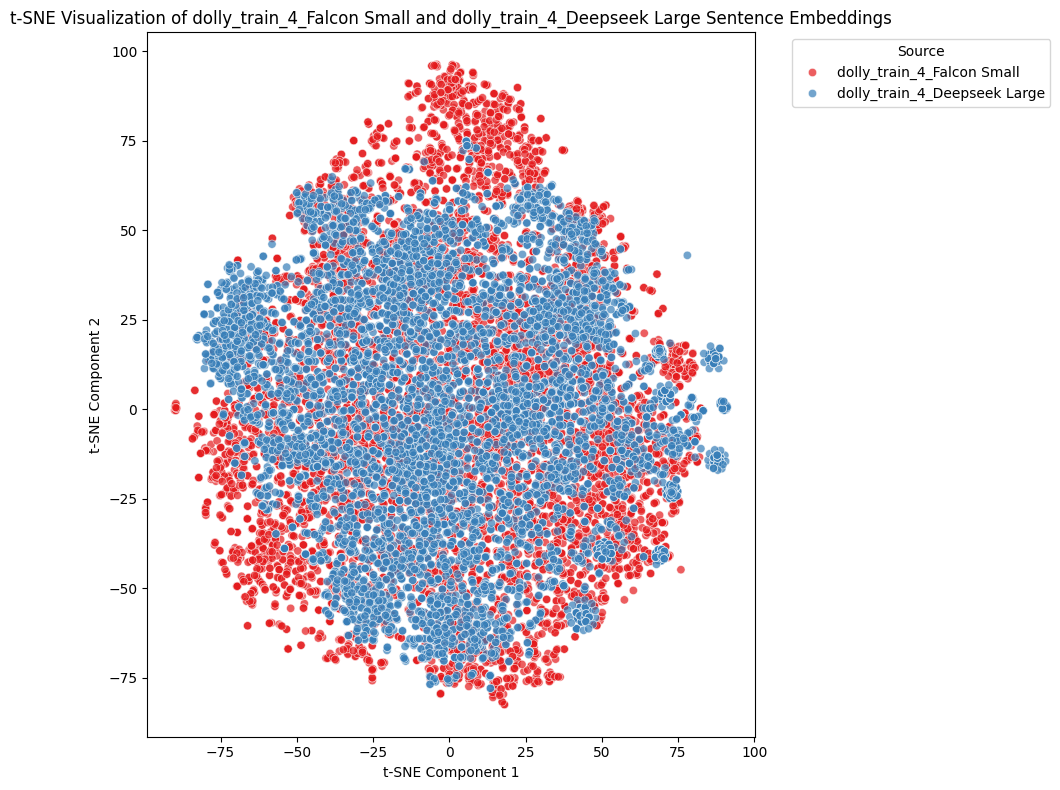

In [41]:
size_1 = "Small"
embedding_1 = "dolly_train_4_Falcon"

size_2 = "Large"
embedding_2 = "dolly_train_4_Deepseek"


tsne_1 = tsne_embeddings[size_1][embedding_1]["embeddings"]
tsne_2 = tsne_embeddings[size_2][embedding_2]["embeddings"]


# Plotting

plt.figure(figsize=(10, 8))

# Combine the embeddings and create labels
combined_embeddings = np.vstack([tsne_1, tsne_2])
labels = np.array([embedding_1 + " " +  size_1] * len(tsne_1) + [embedding_2 + " " + size_2] * len(tsne_2))

sns.scatterplot(
    x=combined_embeddings[:, 0], 
    y=combined_embeddings[:, 1], 
    hue=labels,
    palette='Set1', 
    alpha=0.7
)

plt.title(f"t-SNE Visualization of {embedding_1 + " " +  size_1} and {embedding_2 + " " + size_2} Sentence Embeddings")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Source", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Minimum x values for embeddings 1:  -90.05 and for embeddings 2: -82.96
Maximum x values for embeddings 1:  82.39 and for embeddings 2: 91.12
Minimum y values for embeddings 1:  -82.56 and for embeddings 2: -77.99
Maximum y values for embeddings 1:  96.37 and for embeddings 2: 74.88


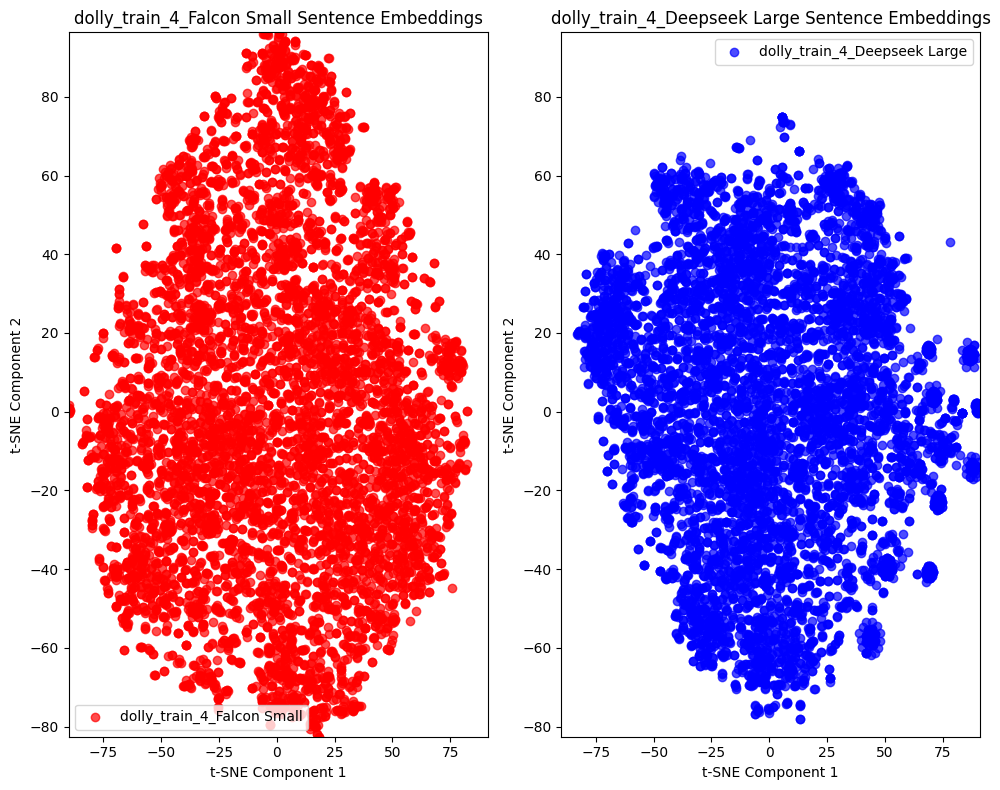

In [43]:
# Plotting two separate scatterplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 8))

# Human embeddings plot
ax1.scatter(
    tsne_1[:, 0],
    tsne_1[:, 1],
    color='red',
    alpha=0.7,
    label=embedding_1 + " " +  size_1
)
ax1.set_title(f"{embedding_1 + " " +  size_1} Sentence Embeddings")
ax1.set_xlabel("t-SNE Component 1")
ax1.set_ylabel("t-SNE Component 2")
ax1.legend()

# Model embeddings plot
ax2.scatter(
    tsne_2[:, 0],
    tsne_2[:, 1],
    color='blue',
    alpha=0.7,
    label=embedding_2 + " " +  size_2
)

ax2.set_title(f"{embedding_2 + " " +  size_2} Sentence Embeddings")
ax2.set_xlabel("t-SNE Component 1")
ax2.set_ylabel("t-SNE Component 2")
ax2.legend()

# Find the min and max values across both datasets to set consistent axis limits
x_min = min(tsne_1[:, 0].min(), tsne_2[:, 0].min())
x_max = max(tsne_1[:, 0].max(), tsne_2[:, 0].max())
y_min = min(tsne_1[:, 1].min(), tsne_2[:, 1].min())
y_max = max(tsne_1[:, 1].max(), tsne_2[:, 1].max())

# Set the same limits for both axes
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)

print("Minimum x values for embeddings 1: ", round(tsne_1[:, 0].min(), 2), "and for embeddings 2:", round(tsne_2[:, 0].min(), 2))
print("Maximum x values for embeddings 1: ", round(tsne_1[:, 0].max(), 2), "and for embeddings 2:", round(tsne_2[:, 0].max(), 2))
print("Minimum y values for embeddings 1: ", round(tsne_1[:, 1].min(), 2), "and for embeddings 2:", round(tsne_2[:, 1].min(), 2))
print("Maximum y values for embeddings 1: ", round(tsne_1[:, 1].max(), 2), "and for embeddings 2:", round(tsne_2[:, 1].max(), 2))

plt.tight_layout()
plt.show()


# Visualizing all datasets

# Visualizing the human sentences

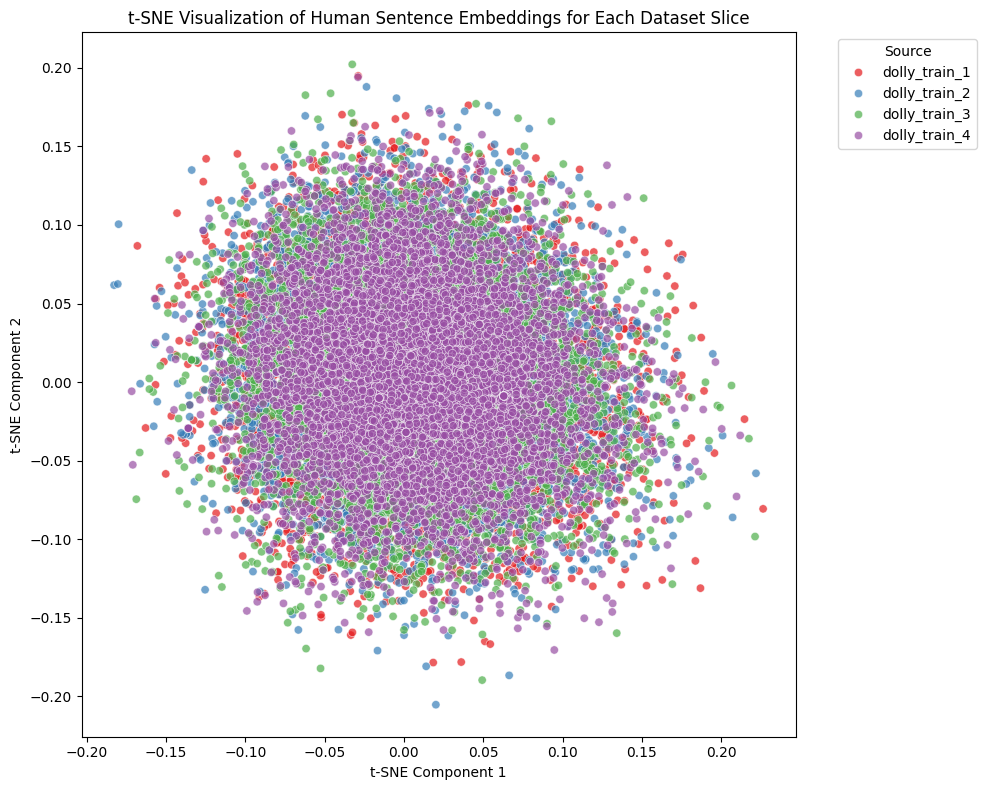

In [ ]:
# Plotting
plt.figure(figsize=(10, 8))

# Combine the embeddings and create labels
combined_embeddings = np.vstack([human_embeddings[f"dolly_train_{i}"]["embeddings"] for i in range(1, 5)])
labels = np.concatenate([[f'dolly_train_{i}']*7000 for i in range(1, 5)])

sns.scatterplot(
    x=combined_embeddings[:, 0], 
    y=combined_embeddings[:, 1], 
    hue=labels,
    palette='Set1', 
    alpha=0.7
)
plt.title("t-SNE Visualization of Human Sentence Embeddings for Each Dataset Slice")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Source", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


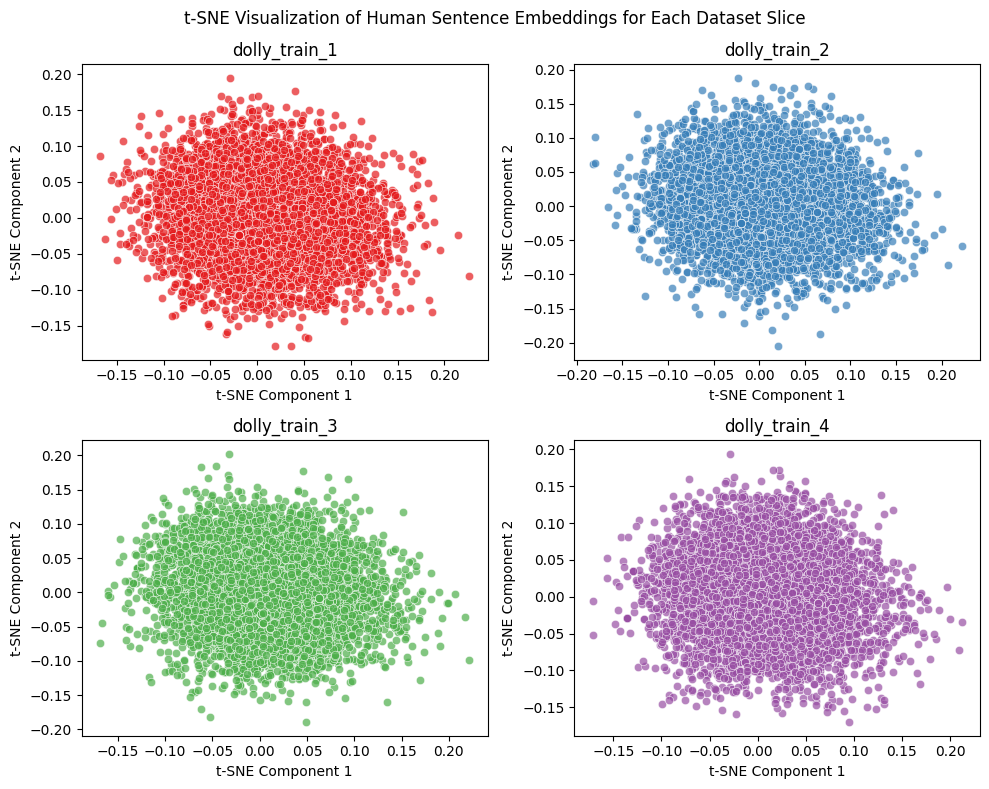

In [ ]:
# Plotting
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# Create a separate plot for each dataset
colors = sns.color_palette('Set1', n_colors=4)

for i, ax in zip(range(1, 5), axes):
    embeddings = human_embeddings[f"dolly_train_{i}"]["embeddings"]
    
    sns.scatterplot(
        x=embeddings[:, 0],
        y=embeddings[:, 1],
        color=colors[i-1],
        alpha=0.7,
        ax=ax
    )
    
    ax.set_title(f"dolly_train_{i}")
    ax.set_xlabel("t-SNE Component 1")
    ax.set_ylabel("t-SNE Component 2")

plt.suptitle("t-SNE Visualization of Human Sentence Embeddings for Each Dataset Slice", y=0.98)
plt.tight_layout()
plt.show()
